<a href="https://colab.research.google.com/github/martinacssll/chemoinformatics/blob/main/MOOC_assignments/QSAR_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scoring Generated Molecules - QSAR model

This activity directly extends the exercise from the previous unit. Use the same Glucocorticoid receptor generated sets, the same DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets, and the same reference chemistry context from CHEMBL2034. Instead of focusing only on visualization, you will now build a small scoring workflow that helps rank molecules from those generated sets and evaluate them against the reference chemistry.

## Learning goals

- Compute synthetic accessibility scores with SAScore.
- Compute drug-likeness scores with QED.
- Design a good project-specific custom score (also using the reference chemistry context).
- Rank the generated compounds and compare the success of the two generators in terms of your scoring criteria.
- Compare the top-ranked molecules from each generator to the reference chemistry and visualize their locations in chemical space.

## Activity overview

Start from the prepared molecular datasets you used in the chemspace activity. The main objective here is to calculate the appropriate **scores** for each molecule and suggest a suitable **ranking strategy**, which would maximize the chance of finding <u>non-steroidal</u>, <u>synthetically accessible</u>, and <u>drug-like</u> compounds in the generated sets. You will also *compare the two generators* in terms of their ability to produce such molecules in terms of their outputs (the DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets).

## Suggested scoring components

Below are three scoring components that you can use to rank the generated molecules, but they are mere suggestions. You are free to design your own scoring strategy, but you must justify your choices.

**1 <u>SAScore</u> for synthetic accessibility**

Use the RDKit-compatible SAScore implementation that is commonly distributed with RDKit contribution scripts.
Remember that lower values are generally better.

**2 <u>QED</u> for drug-likeness**

Use `rdkit.Chem.QED.qed(mol)` to compute a score between 0 and 1.
Higher values are generally better.

**3 A specialized <u>non-steroidal prioritization score</u>**

Build your own score that favors non-steroidal compounds from the generated sets.
The purpose is to prioritize alternatives to steroid-like chemistry while still keeping compounds reasonably accessible and drug-like.

> You are free to define the detection rule, but you must document it. Reasonable options include:

> - using a *SMARTS pattern* for a fused tetracyclic steroid-like core
> - using *ring system heuristics* that detect the characteristic fused four-ring framework
> - using a curated list of steroid reference scaffolds and a *similarity-based penalty*

> The most important requirement is that your score should clearly separate compounds you would consider steroid-like from compounds you would consider non-steroidal. You can use a chemical space visualization to inspect the results of your steroid detection rule and make sure it aligns with your expectations.

**4 <u>QSAR model</u>**

Use the CHEMBL2034 data set to train a simple QSAR model for glucocorticoid receptor activity. Choose a suitable endpoint using the activity charts and train the model using whatever machine learning approach you prefer.

### Example custom score design

One possible form is:

```
score_custom = w1 * QED + w2 * synth_term - w3 * steroid_penalty + w4 * QSAR_predicted_activity
```

where:

- `QED` is scaled between 0 and 1 so that higher values are better
- `synth_term` is a transformed version of SAScore that is also scaled between 0 and 1 (e.g., with a suitable sigmoid function) so that higher values are better
- `steroid_penalty` is 1 for steroid-like molecules and 0 for non-steroidal molecules, or a continuous similarity-based penalty also scaled between 0 and 1
- `QSAR_predicted_activity` is a predicted probability of activity from your QSAR model, scaled between 0 and 1

You may choose the weights in your score manually or use a simple optimization strategy to find weights that maximize the number of non-steroidal, synthetically accessible, and drug-like compounds in the top-ranked molecules from the reference chemistry context (CHEMBL2034).

## Suggested workflow

1. Reuse the prepared generated datasets from the chemspace exercise.

4. Compute QED for each molecule.

5. Compute SAScore for each molecule.

6. Define and compute your steroid or non-steroidal penalty term.

7. Train a QSAR model for glucocorticoid receptor activity and compute predicted activity scores for each molecule.

8. Normalize or transform the score components so they are numerically comparable as outlined in the weighted sum score example above.

9. Construct your custom scoring function (optimize weights if desired).

10. Rank the molecules within each generator output set.

11. Compare the top-ranked molecules from the DrugEx_GT_epsilon_0.6 and GB_GA_mut_r_0.5 sets in terms of their scores and contrast them with the reference chemistry context (CHEMBL2034).

12. Map the top-ranked and bottom-ranked compounds back onto your chemspace visualizations from the previous activity.

## 0. Setup and Datasets



In [1]:
# Download RDKit, the ChEMBL API and sasscorer.py
!pip -q install RDKit
!pip -q install chembl_webresource_client
#!wget -q https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
#!wget -q https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

In [94]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, KFold, GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

import gc

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Molecular generators datasets
import glob

files_drugex = glob.glob('drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/*')
files_gbga = glob.glob('drive/MyDrive/data/GB_GA_mut_r_0.5_10k/*')

# For each molecular generator, upload data as a dataframe
def upload_data(files_list, df_name):
    print("Uploading", files_list)
    df_list = [] # List of datasets in files_list
    for file in files_list:
      # Create a DataFrame
      df = pd.DataFrame(columns=['smiles', 'source'])
      # Read the file
      df['smiles'] = pd.read_csv(file)
      # Add source
      df['source'] = df_name
      # Append to the list of dataframes for data in files_list
      df_list.append(df)
    # Concatenate the data
    df_files = pd.concat(df_list, ignore_index=True)
    return df_files

df_drugex = upload_data(files_drugex, 'DrugEx_GT')
print(len(df_drugex), "entries for DrugEx datasets")
df_gbga = upload_data(files_gbga, 'GB_GA')
print(len(df_gbga), "entries for GB_GA datasets")

# Concatenate in a single DataFrame
df_denovo = pd.concat([df_drugex, df_gbga], ignore_index=True)

Uploading ['drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_4_one_column.csv', 'drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_1_one_column.csv', 'drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_3_one_column.csv', 'drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_0_one_column.csv', 'drive/MyDrive/data/DrugEx_GT_epsilon_0.6_10k/cOS_DrugEx_GT_epsilon_0.6_10k_dis_2_one_column.csv']
49995 entries for DrugEx datasets
Uploading ['drive/MyDrive/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_1_one_column.csv', 'drive/MyDrive/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_2_one_column.csv', 'drive/MyDrive/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_4_one_column.csv', 'drive/MyDrive/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_0_one_column.csv', 'drive/MyDrive/data/GB_GA_mut_r_0.5_10k/cOS_GB_GA_mut_r_0.5_10k_dis_3_one_column.csv']
49995 entries 

For the ChEMBL reference chemistry dataset, I retrieve <u>only IC50 data</u> (<u>binding assays</u>), as they are the most abundant for the glucocorticoid receptor. Ki would theoretically be a better choice, since it measures thermodynamic affinity and is less dependant on the assay type. However, for some data the reported Ki is calculated from experimental IC50, which would make the Ki values not necessarily more precise than IC50 and might add propagation error. For this reason, combined with the need for the QSAR model to cover a chemical space as broad as possible as it will be used to score *de novo* generated molecules that have many different structures, the larger IC50 dataset is preferred.

In [5]:
# ChEMBL dataset
from chembl_webresource_client.new_client import new_client

# ChEMBL ID of the glucocorticoid receptor
target_chembl_id = 'CHEMBL2034'

# Establish a communication channel with the activity and assay resources in ChEMBL
activity = new_client.activity

# Fields to retrieve
desired_columns = [
    'molecule_chembl_id', 'canonical_smiles',
    'standard_type', 'standard_relation', 'standard_value', 'standard_units',
    'assay_chembl_id', 'assay_type', 'assay_description', 'data_validity_comment'
]

# Retrieve active compounds for the given receptor, together with selected attributes
activities = activity.filter(
    target_chembl_id=target_chembl_id,
    standard_type__exact="IC50",
    standard_relation__exact='=',
    assay_type__exact='B'
).only(desired_columns)

In [6]:
# Convert to a Pandas DataFrame
df_acts = pd.DataFrame(list(activities))
print(f"Retrieved {len(df_acts)} total raw records for this receptor.")

# Save to a file
# Clean it up (delete redundant columns)
df_acts = df_acts[[col for col in desired_columns]]

# Save it to a file
df_acts.to_csv('drive/MyDrive/data/reference_chemistry.csv', index=False)

Retrieved 2591 total raw records for this receptor.


In [7]:
# Retrieve confidence scores for the assays
assay = new_client.assay

unique_assay_ids = df_acts['assay_chembl_id'].unique().tolist()
assays = assay.filter(assay_chembl_id__in=unique_assay_ids).only(
    ['assay_chembl_id', 'confidence_score']
)
df_assay = pd.DataFrame(assays)

# Merge
df_refchem = df_acts.merge(df_assay, on='assay_chembl_id', how='left')

## 1. Data curation

- For the ChEMBL reference chemistry, inspect and eventually exclude entries with a warning comment from curators or a low confidence score; inspect and eventually harmonize units; exclude entries with inconsistent units of measure

- **Validate SMILES strings**: for SMILE-based files, convert the SMILES strings with `Chem.MolFromSmiles`; if a structure is invalid, RDKit fails to parse it; **canonicalization**: generate canonical SMILES with `Chem.MolToSmiles`

- **Salts / Mixtures**: check numeber of fragments, then keep the largest if appropriate

- **Neutralization**: molecules generated *de novo* might have unphysical protonation states, and the same molecule might occur multiple times with different protonation states; hence, to make all entries comparable all structures are neutralized

- **Deduplication**: same molecule, salts, mixtures ( check canonical SMILES); for the reference chemistry dataset, check if activity values are compatible before merging duplicates - if not, exclude the data

- For the ChEMBL reference chemistry, check molecular weights: too high values point to structures not comparable with small molecules, such as peptides

- Generate clean datasets by dropping invalid entries as determined in the steps above; for the reference chemistry dataset: select single compounds and actives with similar values and merge those; exclude remaining flagged compounds from this dataset; check the pIC50 values to spot eventual artefacts

In [8]:
# Add a flag to exclude entries
df_denovo['flag_exclude'] = False
df_refchem['flag_exclude'] = False

### Data curator warnings, confidence scores, units of measure - ChEMBL dataset

- Inspect *data curator warning comments* and *confidence scores*

- Inspect IC50 *units* of measure

In [9]:
# For the reference chemistry dataset, inspect and exclude entries with a data curator comment
df_refchem.loc[df_refchem['data_validity_comment'].notna(), 'flag_exclude'] = True
df_refchem[df_refchem['data_validity_comment'].notna()]

,molecule_chembl_id,canonical_smiles,standard_type,standard_relation,standard_value,standard_units,assay_chembl_id,assay_type,assay_description,data_validity_comment,confidence_score,flag_exclude
208,CHEMBL1276308,CC#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[...,IC50,=,0.008,nM,CHEMBL827972,B,Inhibition of CHO-K1 cells expressing glucocor...,Outside typical range,8,True


In [10]:
# For the reference chemistry dataset, inspect the units of measure and range of the IC50 values
print("Units of measure of IC50:", df_refchem['standard_units'].unique())
# Convert to number from string the activity values
df_refchem['standard_value'] = pd.to_numeric(df_refchem['standard_value'])

Units of measure of IC50: ['nM']


In [11]:
# For the reference chemistry dataset, inspect and exclude entries with a low confidence score (< 8)
# Inspect reference score values
print(f"Min confidence_score: {df_refchem['confidence_score'].min()}\nMax confidence_score: {df_refchem['confidence_score'].max()}")
print(f"Unique confidence_score values: {df_refchem['confidence_score'].unique()}")

# Nothing to exclude based on confidence score

Min confidence_score: 8
Max confidence_score: 9
Unique confidence_score values: [9 8]


### SMILES validation and canonicalization

- **Validate SMILES strings**: for SMILE-based files, convert the SMILES strings with `Chem.MolFromSmiles`; if a structure is invalid, RDKit fails to parse it

- **Canonicalization**: generate canonical SMILES with `Chem.MolToSmiles`

In [12]:
data = [(df_denovo, 'De novo'), (df_refchem, 'Reference chemistry')]

In [13]:
# Validate SMILES
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  # Convert from SMILES to Mol object
  smiles_col = "smiles" if "smiles" in df.columns else "canonical_smiles"
  df["mol"] = df[smiles_col].apply(smiles_to_mol)
  df["flag_invalid_smiles"] = df["mol"].isna()
  # Check if there are any invalid SMILES
  print(df_name, "has", (df["flag_invalid_smiles"]).sum(), "invalid SMILES")
  # Exclude entries with invalid SMILES
  df.loc[df['flag_invalid_smiles'], 'flag_exclude'] = True

De novo has 0 invalid SMILES
Reference chemistry has 1 invalid SMILES


In [14]:
df_refchem[df_refchem['flag_invalid_smiles']]

,molecule_chembl_id,canonical_smiles,standard_type,standard_relation,standard_value,standard_units,assay_chembl_id,assay_type,assay_description,data_validity_comment,confidence_score,flag_exclude,mol,flag_invalid_smiles
1000,CHEMBL1366,None,IC50,=,1317.0,nM,CHEMBL1909150,B,DRUGMATRIX: Glucocorticoid radioligand binding...,None,8,True,None,True


In [15]:
# Generate canonical smiles
def canonical_smiles(mol):
    if mol is None:
        return np.nan
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  df["canonical_smiles_rdkit"] = df["mol"].apply(canonical_smiles)

### Salts / Mixtures

- Check the *number of fragments* and eventually keep the largest fragment

In [16]:
# Count fragments to identify salt and mixtures
def count_fragments(mol):
    if mol is None:
        return np.nan
    return len(Chem.GetMolFrags(mol))

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  df["n_fragments"] = df["mol"].apply(count_fragments)
  df["flag_multiple_fragments"] = df["n_fragments"] > 1
  print(f"{df_name} has {df["flag_multiple_fragments"].sum()} entries with more than one fragment")

De novo has 0 entries with more than one fragment
Reference chemistry has 5 entries with more than one fragment


Reference chemistry
    molecule_chembl_id  n_fragments
98         CHEMBL63241          2.0
99         CHEMBL63241          2.0
460       CHEMBL541908          2.0
461       CHEMBL537887          2.0
740      CHEMBL1094536          2.0


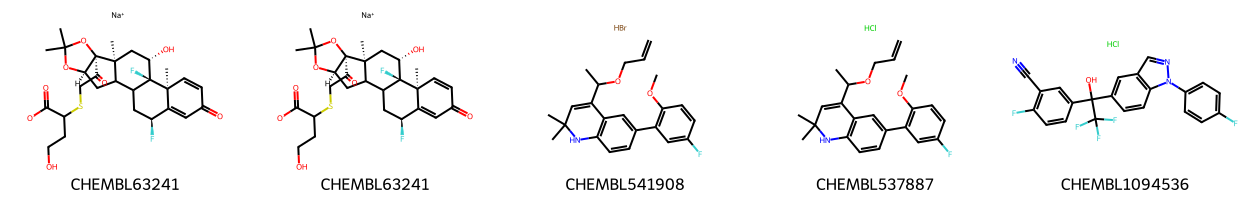

In [17]:
# Inspect the entries with more than one fragment
print("Reference chemistry")
print(df_refchem[df_refchem["flag_multiple_fragments"]][["molecule_chembl_id", "n_fragments"]])

multfrag_refchem = df_refchem[df_refchem["flag_multiple_fragments"]].copy()
MolsToGridImage(
    multfrag_refchem["mol"].tolist(),
    legends=multfrag_refchem["molecule_chembl_id"].tolist(),
    molsPerRow=5,
    subImgSize=(250, 200)
)

All the structures with more than one fragment are salts of a main structure, hence it is appropriate to keep only the largest fragment.

In [18]:
# Keep the largest fragment
fragment_chooser = rdMolStandardize.LargestFragmentChooser()

def largest_fragment_mol(mol):
    if mol is None:
        return None
    try:
        return fragment_chooser.choose(mol) # choose the largest fragment
    except Exception:
        return mol

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  df["parent_mol"] = df["mol"].apply(largest_fragment_mol)
  df["parent_smiles"] = df["parent_mol"].apply(canonical_smiles)

Output streaming troncato alle ultime 5000 righe.
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running LargestFragmentChooser
[13:58:20] Running Largest

### Neutralization

- Neutralize all molecules

In [19]:
# Check the charge of all entries
def formal_charge(mol):
    if mol is None:
        return None
    return Chem.GetFormalCharge(mol)

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  df["charge"] = df["parent_mol"].apply(formal_charge)
  print(f"{df_name} has {len(df[(df['charge'] != 0) & df['charge'].notna()])} charged entries.")

De novo has 238 charged entries.
Reference chemistry has 2 charged entries.


In [20]:
# Neutralize
uncharger = rdMolStandardize.Uncharger()

def neutralize_mol(mol):
    if mol is None:
        return None
    try:
        return uncharger.uncharge(mol)
    except Exception:
        return mol

for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  df["parent_mol_neut"] = df["parent_mol"].apply(neutralize_mol)
  df["parent_smiles_neut"] = df["parent_mol_neut"].apply(canonical_smiles)
  df["charge_neut"] = df["parent_mol_neut"].apply(formal_charge)

Output streaming troncato alle ultime 5000 righe.
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Uncharger
[13:58:49] Running Unc

In [21]:
for dataset in data:
  df = dataset[0]
  df_name = dataset[1]
  print(f"{df_name} has {len(df[(df['charge_neut'] != 0) & df['charge_neut'].notna()])} remaining charged entries after neutralization.")

De novo has 59 remaining charged entries after neutralization.
Reference chemistry has 0 remaining charged entries after neutralization.


### Deduplication

- Remove duplicates; for the reference chemistry dataset, check that activity values in duplicates are similar - if yes, average them, else exclude all entries

In [22]:
# De novo dataset - Flag molecules that are identical according to RDKit canonical SMILES (keep the first occurrence)
df_denovo['flag_duplicate_parent_neut'] = df_denovo.duplicated(subset=['parent_smiles_neut', 'source'], keep='first') & df_denovo["parent_smiles_neut"].notna()
print(f"DrugEx_GT has {(df_denovo[df_denovo['source'] == 'DrugEx_GT']["flag_duplicate_parent_neut"]).sum()} RDKit SMILES duplicates")
print(f"GB_GA has {(df_denovo[df_denovo['source'] == 'GB_GA']["flag_duplicate_parent_neut"]).sum()} RDKit SMILES duplicates")

# Exclude occurrences that are not the first (I don't need activity data so I'll just keep the first occurrence - If I did, I would have to look at the values to check if they are coherent before grouping them)
df_denovo.loc[df_denovo["flag_duplicate_parent_neut"], "flag_exclude"] = True

DrugEx_GT has 25 RDKit SMILES duplicates
GB_GA has 89 RDKit SMILES duplicates


In [23]:
# Check if activities can be merged for duplicates in the reference chemistry dataset
# 1. Convert to pIC50
df_refchem['pIC50'] = 9 - np.log10(df_refchem['standard_value']) # conversion nM -> M, then -log10

# 2. Group by SMILES
grouped = df_refchem.groupby('parent_smiles_neut')['pIC50'].agg(
    ['mean', 'median', 'std', 'count', 'min', 'max']
).reset_index()
grouped['range'] = grouped['max'] - grouped['min']

# 3. Check if activity values are similar for duplicates
def classify(r, agree_thresh=0.5, borderline_thresh=1.0):
    if r['count'] == 1:                   # entries with no duplicates
        return 'single'
    elif r['range'] <= agree_thresh:      # entries with low range between duplicates
        return 'agree'
    elif r['range'] <= borderline_thresh: # entries with borderline range between duplicates
        return 'borderline'
    else:                                 # entries with high range between duplicates
        return 'disagreement'

grouped['flag_status'] = grouped.apply(classify, axis=1)

# 4. Merge info in the original dataframe
df_refchem = df_refchem.merge(grouped[['parent_smiles_neut', 'flag_status', 'range']], on='parent_smiles_neut', how='left')

# 5. Exclude 'disagreement'
df_refchem.loc[df_refchem['flag_status'] == 'disagreement', 'flag_exclude'] = True

### Molecular weigth

- Calculate and inspect molecular weights, as too high values belong to structures such as peptides, that should be excluded from the reference set

In [24]:
# Calculate molecular weight
def molecular_weight(mol):
    if mol is None:
        return None
    return Descriptors.MolWt(mol)

df_refchem["MW"] = df_refchem["mol"].apply(molecular_weight)
df_denovo["MW"] = df_denovo["mol"].apply(molecular_weight)

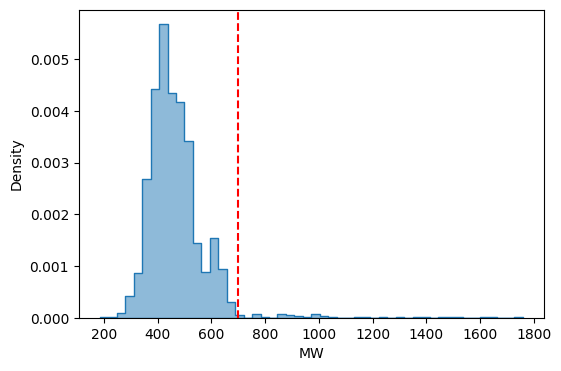

count    2590.000000
mean      468.290842
std       114.508422
min       185.251000
25%       401.472000
50%       449.355500
75%       510.389750
max      1758.090000
Name: MW, dtype: float64
Entries above 700: 44
Entries above 1000: 15


In [25]:
# Inspect MW distribution for reference chemistry dataset
plt.figure(figsize=(6, 4))
sns.histplot(data=df_refchem, x='MW', bins=50, alpha=0.5, element='step', stat='density', common_norm=False)
plt.axvline(700, color='red', linestyle='--', label='proposed cutoff')
plt.xlabel('MW')
plt.show()

print(df_refchem['MW'].describe())
print(f"Entries above 700: {(df_refchem['MW'] > 700).sum()}")
print(f"Entries above 1000: {(df_refchem['MW'] > 1000).sum()}")

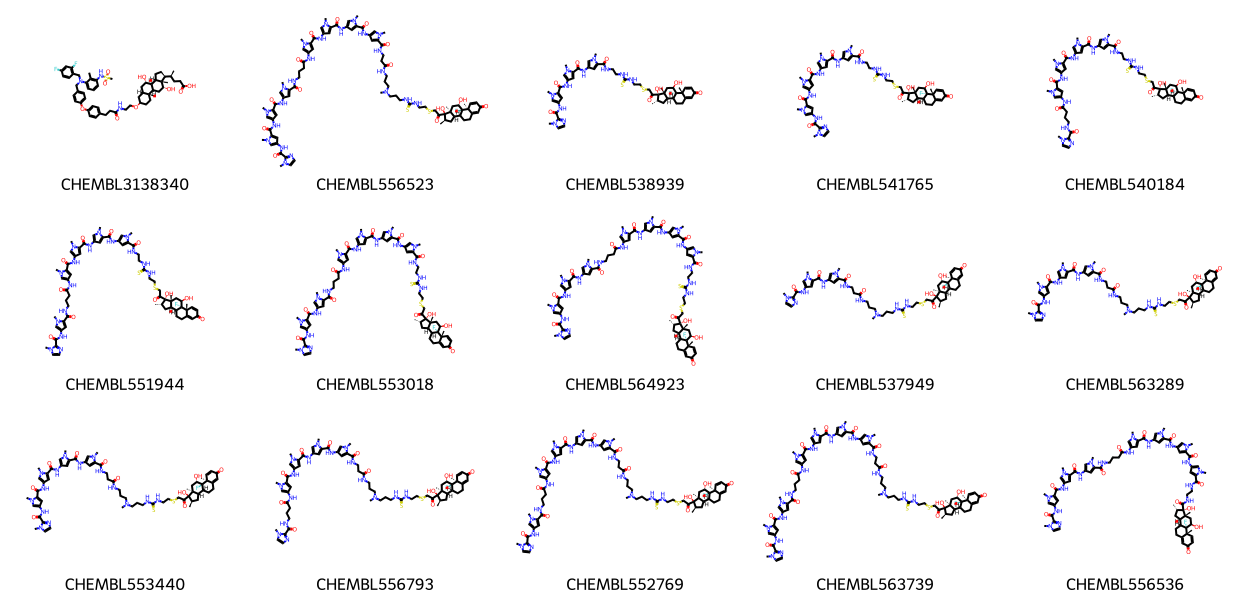

In [26]:
# Visually inspect entries with MW > 1000
#high_mw = df_refchem[(df_refchem["MW"] > 700) & (df_refchem["MW"] < 1000)].copy()
high_mw = df_refchem[df_refchem["MW"] > 1000].copy()
MolsToGridImage(
    high_mw["mol"].tolist(),
    legends=high_mw["molecule_chembl_id"].tolist(),
    molsPerRow=5,
    subImgSize=(250, 200)
)

I exclude entries with MW > 1000, as they are all large peptides in a dataset made of small molecules, and hence they would add noise to the QSAR model.

In [27]:
# Flag entries with MW > 1000
df_refchem["flag_largeMW"] = df_refchem["MW"] > 1000
df_refchem.loc[df_refchem["flag_largeMW"], "flag_exclude"] = True

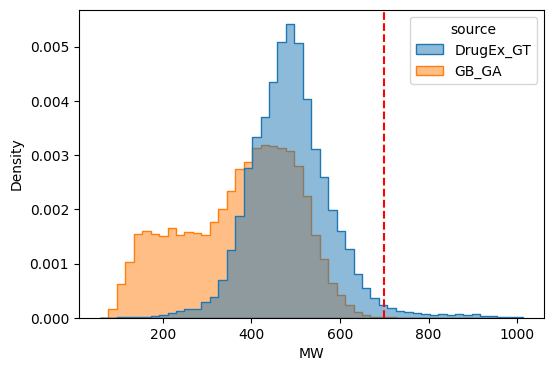

count    99990.000000
mean       430.204326
std        126.303211
min         58.124000
25%        367.486750
50%        449.330500
75%        510.556000
max       1012.207000
Name: MW, dtype: float64
Entries above 700: 1049
Entries above 1000: 7


In [28]:
# Inspect MW distribution for de novo dataset
plt.figure(figsize=(6, 4))
sns.histplot(data=df_denovo, x='MW', hue='source', bins=50, alpha=0.5, element='step', stat='density', common_norm=False)
plt.axvline(700, color='red', linestyle='--', label='proposed cutoff')
plt.xlabel('MW')
plt.show()

print(df_denovo['MW'].describe())
print(f"Entries above 700: {(df_denovo['MW'] > 700).sum()}")
print(f"Entries above 1000: {(df_denovo['MW'] > 1000).sum()}")

/usr/local/lib/python3.13/dist-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


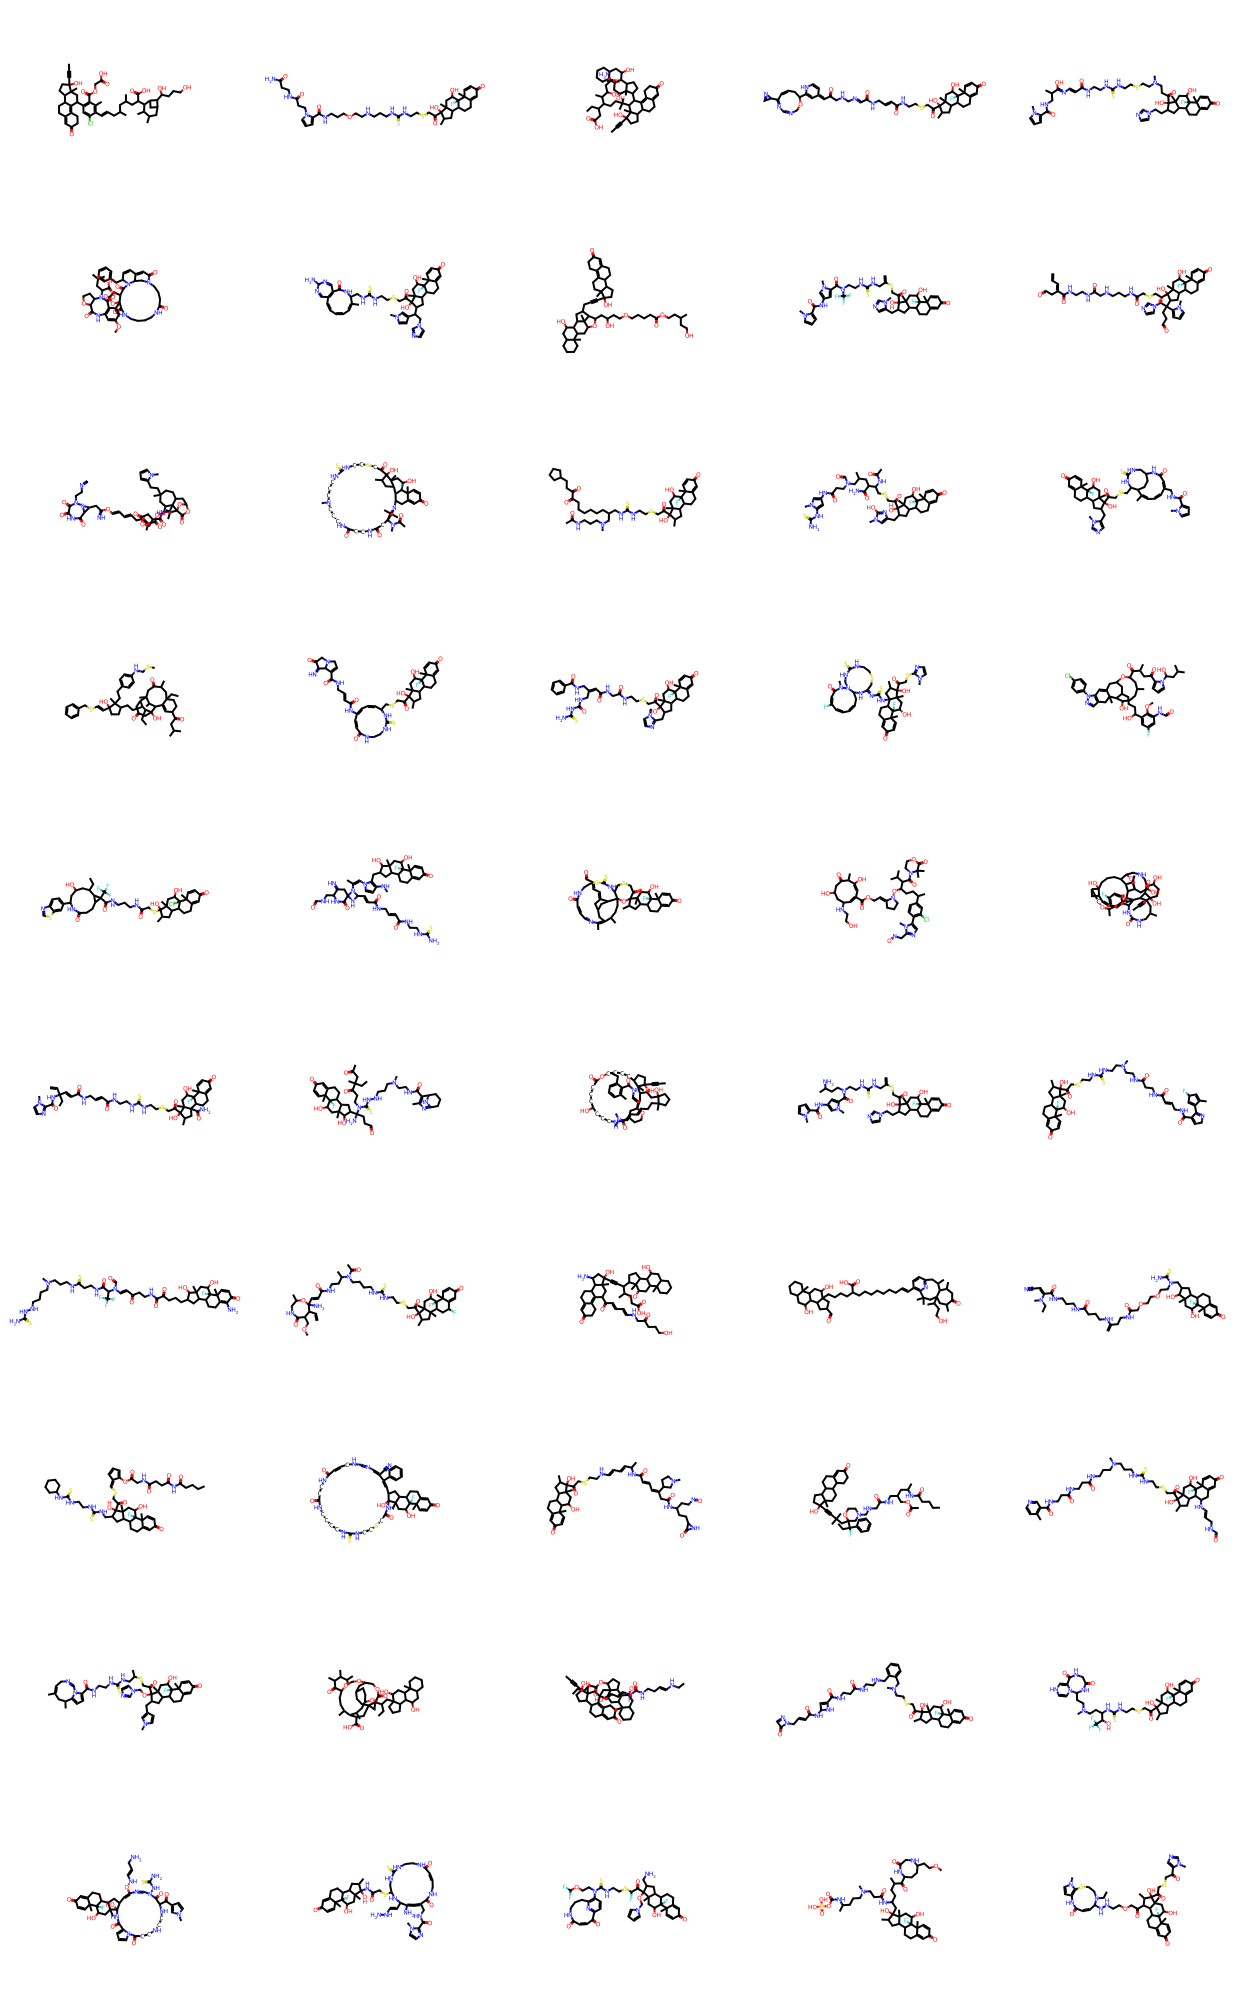

In [29]:
# Visually inspect entries with MW > 1000
high_mw = df_denovo[df_denovo["MW"] > 900].copy()
MolsToGridImage(
    high_mw["mol"].tolist(),
    molsPerRow=5,
    subImgSize=(250, 200)
)

### Clean dataset

- Generate clean *de novo* and reference datasets by excluding invalid entries as determined in the steps above

- For the reference chemistry dataset: after excluding flagged entries, check the pIC50 values to spot eventual artefacts

In [30]:
# Recap columns in df_refchem and df_denovo
# Columns with flags for data quality
columns_flags_denovo = ['flag_exclude',
                        'flag_invalid_smiles', 'n_fragments', 'flag_multiple_fragments',
                        'flag_duplicate_parent_neut']
columns_flags_refchem = ['flag_exclude',
                         'data_validity_comment', 'confidence_score',
                         'flag_invalid_smiles', 'n_fragments', 'flag_multiple_fragments',
                         'flag_status', 'range',
                         'flag_largeMW']

# Columns with data relative to raw (not standardized) and not neutralized structures
columns_rawstruct = ['smiles', 'mol', 'canonical_smiles_rdkit',
                     'parent_mol', 'parent_smiles', 'charge']

# Columns with data relative to final (standardized and neutralized) structures
columns_finalstruct = ['parent_mol_neut', 'parent_smiles_neut',
                       'charge_neut', 'MW']

# Columns with assay and activity data (ChEMBL dataset)
columns_assay = ['assay_chembl_id', 'assay_type', 'assay_description']
columns_activity_complete = ['standard_type', 'standard_relation', 'standard_value', 'standard_units',
                             'pIC50']
columns_activity = ['pIC50']

# Remaining de novo dataset column: 'source'

# Remaining reference chemistry dataset column: 'molecule_chembl_id'

In [31]:
# De novo dataset
df_denovo_clean = df_denovo[df_denovo['flag_exclude'] == False].copy()
print(f"Excluded {len(df_denovo) - len(df_denovo_clean)} entries for de novo dataset")

# Keep only source, Mol and SMILES columns
df_denovo_clean = df_denovo_clean[['parent_mol_neut', 'parent_smiles_neut', 'source']].copy()

# Rename columns for clarity
df_denovo_clean.rename(columns={
    'parent_mol_neut': 'mol',
    'parent_smiles_neut': 'canonical_smiles'
}, inplace=True)

# Save to a file
df_denovo_clean.to_csv('drive/MyDrive/data/df_denovo_clean.csv', index=False)

Excluded 114 entries for de novo dataset


In [32]:
df_denovo_clean.head()

,mol,canonical_smiles,source
0,<rdkit.Chem.rdchem.Mol object at 0x78d3f92582e0>,Cc1cccc(N(CC(C)C)C(=O)COC(=O)c2ccc3c(c2)COC(C2...,DrugEx_GT
1,<rdkit.Chem.rdchem.Mol object at 0x78d3f92584a0>,Cc1cc(-c2ccc(C(C)COCc3ccccc3)c3cc[nH]c23)c(C=N...,DrugEx_GT
2,<rdkit.Chem.rdchem.Mol object at 0x78d3f9258510>,CC(=CC=C1C=CC(C)(c2ccccn2)CO1)C1C(=N)N1C(C1CC1...,DrugEx_GT
3,<rdkit.Chem.rdchem.Mol object at 0x78d3f9258580>,CC#CC1(O)CCC2C3CCC4=CC(=O)CCC4=C3C(c3ccc(CNCCO...,DrugEx_GT
4,<rdkit.Chem.rdchem.Mol object at 0x78d3f92585f0>,CC(C)CC(O)(Cc1cc2cc(-c3ccccc3S(N)(=O)=O)ncc2[n...,DrugEx_GT


In [33]:
# Reference chemistry dataset
# Exclude invalid entries
df_refchem_filt = df_refchem[df_refchem['flag_exclude'] == False].copy()
print(f"Excluded {len(df_refchem) - len(df_refchem_filt)} entries for reference chemistry dataset")

Excluded 440 entries for reference chemistry dataset


In [34]:
df_refchem_clean = (
    df_refchem_filt.groupby('parent_smiles_neut', as_index=False)
    .agg({
        'parent_mol_neut': 'first',
        'parent_smiles_neut': 'first',
        'pIC50': 'mean',
        'molecule_chembl_id': lambda x: ';'.join(sorted(set(x)))
    })
)

# Rename columns for clarity
df_refchem_clean.rename(columns={
    'parent_mol_neut': 'mol',
    'parent_smiles_neut': 'canonical_smiles',
}, inplace=True)

# Save to a file
df_refchem_clean.to_csv('drive/MyDrive/data/df_refchem_clean.csv', index=False)

In [35]:
df_refchem_clean.head()

,mol,canonical_smiles,pIC50,molecule_chembl_id
0,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21d20>,C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@...,6.826814,CHEMBL2107797
1,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b3d1c0>,C#CC1=C(SCC(=O)c2ccccc2)NC(C)=C(C(C)=O)C1c1cccs1,5.730487,CHEMBL5267245
2,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21b60>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4...,6.363512,CHEMBL1162
3,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b211c0>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C...,6.679854,CHEMBL241694
4,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21a10>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,5.365120,CHEMBL1479


In [36]:
print(f"De novo dataset: {len(df_denovo_clean)} entries")
print(f"Reference chemistry dataset: {len(df_refchem_clean)} entries")

De novo dataset: 99876 entries
Reference chemistry dataset: 1736 entries


#### pIC50 values - ChEMBL dataset

General reference values:

| IC50 (nM) | pIC50 |
|-----------|-------|
| 1         | 9.0   |
| 10        | 8.0   |
| 100       | 7.0   |
| 1,000     | 6.0   |
| 10,000    | 5.0   |
| 100,000   | 4.0   |

- **Active**: $\text{IC50} ≤ 1000 \text{ nM}$ ($\text{pIC50} ≥ 6$)
- **Inactive**: $\text{IC50} > 10000 \text{ nM}$ ($\text{pIC50} < 5$)

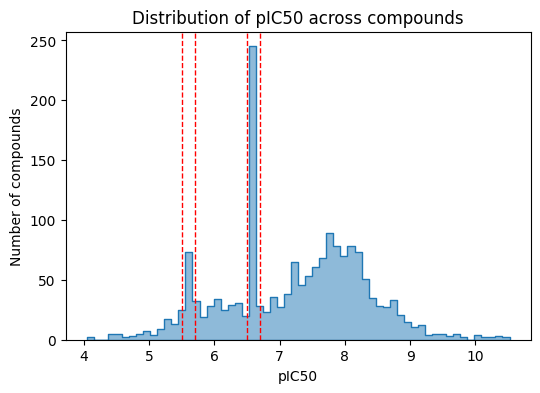

In [37]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_refchem_clean, x='pIC50', bins=60, alpha=0.5, element='step')

plt.axvline(x=5.5, color='red', linestyle='--', linewidth=1)
plt.axvline(x=5.7, color='red', linestyle='--', linewidth=1)
plt.axvline(x=6.5, color='red', linestyle='--', linewidth=1)
plt.axvline(x=6.7, color='red', linestyle='--', linewidth=1)

plt.xlabel('pIC50')
plt.ylabel('Number of compounds')
plt.title('Distribution of pIC50 across compounds')
plt.show()

The two spikes enclosed by the red dashed lines hint at possible artefacts in the data. The following cells investigate them.

In [38]:
# Investigate the spike between pIC50 5 and 6
# Find what's contributing to the spike
spike_compounds = df_refchem_clean[(df_refchem_clean['pIC50'] > 5.5) & (df_refchem_clean['pIC50'] < 5.7)]
print(f"Found {len(spike_compounds)} compounds in the given range")

# Check if the same exact value is reported across many entries
value_counts = spike_compounds['pIC50'].value_counts()
value_counts[value_counts > 1]

Found 99 compounds in the given range


,count
pIC50,
5.560667,57
5.677781,3
5.688246,2
5.698970,2
5.657577,2
5.501689,2


In [39]:
# Inspect the assay type of these compounds
cols = ['parent_smiles_neut', 'parent_mol_neut', 'pIC50', 'molecule_chembl_id', 'assay_chembl_id', 'assay_description']
spike_data = df_refchem[(df_refchem['pIC50'] > 5.560666) & (df_refchem['pIC50'] < 5.560668)][cols]
spike_data['assay_chembl_id'].value_counts()

,count
assay_chembl_id,
CHEMBL5733596,58
CHEMBL5238554,1


In [40]:
# Investigate the spike between pIC50 6 and 7
# Find what's contributing to the spike
spike_compounds = df_refchem_clean[(df_refchem_clean['pIC50'] > 6.5) & (df_refchem_clean['pIC50'] < 6.7)]
print(f"Found {len(spike_compounds)} compounds in the given range")

# Check if the same exact value is reported across many entries
value_counts = spike_compounds['pIC50'].value_counts()
value_counts[value_counts > 1]

Found 268 compounds in the given range


,count
pIC50,
6.560667,221
6.657577,4
6.638272,4
6.585027,3
6.698970,3
6.537602,3
6.602060,3
6.599998,2
6.677781,2


In [41]:
# Inspect the assay type of these compounds
cols = ['parent_smiles_neut', 'parent_mol_neut', 'pIC50', 'molecule_chembl_id', 'assay_chembl_id', 'assay_description']
spike_data = df_refchem[(df_refchem['pIC50'] > 6.560666) & (df_refchem['pIC50'] < 6.560668)][cols]
spike_data['assay_chembl_id'].value_counts()

,count
assay_chembl_id,
CHEMBL5733596,219
CHEMBL889784,1
CHEMBL899205,1


Both these spikes arise from activity values obtained with the same assay (CHEMBL5733596). The following cells indagate it further.

In [42]:
# How many unique pIC50 values does this assay report?
df_refchem[df_refchem['assay_chembl_id'] == 'CHEMBL5733596']['pIC50'].value_counts()

,count
pIC50,
6.560667,219
5.560667,58


In [43]:
# Check description of the assay
list(df_refchem[df_refchem['assay_chembl_id'] == 'CHEMBL5733596']['assay_description'])[0]

'Biological Evaluation: The assay was performed using H4 neuroglioma cells and using indirect immunofluorescence detection of the endogenous GR receptor. Fixative: 4% PFA. Permeabilization buffer: 0.3% Triton X-100 in PBS. Primary antibody: 1:200 in 5% BSA block. Secondary antibody: 1:800 in 5% BSA block. HCS Cell Mask: 1:6000 in PBS. DAPI: 100 ng/ml.'

In [44]:
# Is this assay labeled as binding?
df_refchem[df_refchem['assay_chembl_id'] == 'CHEMBL5733596']['assay_type'].unique()

array(['B'], dtype=object)

The assay is not a binding assay, so I exlude it from the dataset.

In [45]:
# Exclude it from the dataset
df_refchem.loc[df_refchem['assay_chembl_id'] == 'CHEMBL5733596', 'flag_exclude'] = True
df_refchem['flag_assay_issue'] = df_refchem['assay_chembl_id'] == 'CHEMBL5733596'

In [46]:
# Rerun the merging step of the df_refchem dataset
# Exclude invalid entries
df_refchem_filt = df_refchem[df_refchem['flag_exclude'] == False].copy()
print(f"Excluded {len(df_refchem) - len(df_refchem_filt)} entries for reference chemistry dataset")

df_refchem_clean = (
    df_refchem_filt.groupby('parent_smiles_neut', as_index=False)
    .agg({
        'parent_mol_neut': 'first',
        'parent_smiles_neut': 'first',
        'pIC50': 'mean',
        'molecule_chembl_id': lambda x: ';'.join(sorted(set(x)))
    })
)

# Rename columns for clarity
df_refchem_clean.rename(columns={
    'parent_mol_neut': 'mol',
    'parent_smiles_neut': 'canonical_smiles',
}, inplace=True)

# Save to a file
df_refchem_clean.to_csv('drive/MyDrive/data/df_refchem_clean.csv', index=False)

Excluded 717 entries for reference chemistry dataset


In [47]:
df_refchem_clean.head()

,mol,canonical_smiles,pIC50,molecule_chembl_id
0,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21d20>,C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@...,6.826814,CHEMBL2107797
1,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b3d1c0>,C#CC1=C(SCC(=O)c2ccccc2)NC(C)=C(C(C)=O)C1c1cccs1,5.730487,CHEMBL5267245
2,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21b60>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4...,6.363512,CHEMBL1162
3,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b211c0>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C...,6.679854,CHEMBL241694
4,<rdkit.Chem.rdchem.Mol object at 0x78d3f3b21a10>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,5.365120,CHEMBL1479


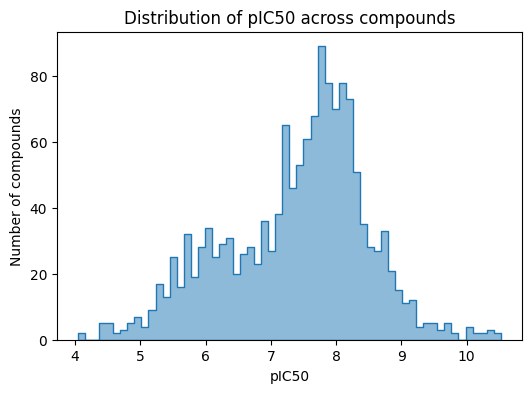

In [48]:
# Check pIC50 distribution again
plt.figure(figsize=(6, 4))
sns.histplot(data=df_refchem_clean, x='pIC50', bins=60, alpha=0.5, element='step')

plt.xlabel('pIC50')
plt.ylabel('Number of compounds')
plt.title('Distribution of pIC50 across compounds')
plt.show()

In [49]:
print(f"De novo dataset: {len(df_denovo_clean)} entries")
print(f"Reference chemistry dataset: {len(df_refchem_clean)} entries")

De novo dataset: 99876 entries
Reference chemistry dataset: 1460 entries


In [50]:
# Save also raw datasets to a file
df_refchem.to_csv('drive/MyDrive/data/df_refchem_raw.csv', index=False)
df_denovo.to_csv('drive/MyDrive/data/df_denovo_raw.csv', index=False)

## 2. Descriptors

Calculate **fingerprints** and **physicochemical descriptors**. Descriptors are selected so that they are not overly correlated.

- **Fingerprints**: Morgan, radius 2, 2048 bit
- **Physicochemical descriptors**:
  - MW, LogP, TPSA, HBD
  - Rotatable bonds, aromatic ring count, fraction Csp3

In [51]:
# Fingerprints
def morgan_fingerprints(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    fp = mfpgen.GetFingerprintAsNumPy(mol)  # as numpy array for sklearn
    return fp

df_refchem_clean['fp'] = df_refchem_clean['mol'].apply(morgan_fingerprints)
df_denovo_clean['fp'] = df_denovo_clean['mol'].apply(morgan_fingerprints)

In [52]:
descriptor_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']

# Descriptors
def calc_descriptors(mol):
    if mol is None:
        return None
    return pd.Series({
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3(mol)
    })

df_refchem_clean[descriptor_cols] = df_refchem_clean['mol'].apply(calc_descriptors)
df_denovo_clean[descriptor_cols] = df_denovo_clean['mol'].apply(calc_descriptors)

The following cells inspect the descriptor values to spot invalid values and low variance descriptors (this is important for the QSAR training set) and to check distributions. Correlation is also checked.

In [53]:
# Inspect values
desc_df_refchem = df_refchem_clean[descriptor_cols].copy()
desc_df_denovo = df_denovo_clean[descriptor_cols].copy()

print("Reference chemistry dataset")
print(desc_df_refchem.describe())
print("\nDe novo dataset")
print(desc_df_denovo[descriptor_cols].describe())

Reference chemistry dataset
                MW         LogP         TPSA          HBD     RotBonds  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean    470.508961     5.075955    75.264863     1.753425     5.500685   
std     101.661425     1.291301    33.263348     1.015045     2.937900   
min     185.251000     0.620500    12.360000     0.000000     0.000000   
25%     400.375000     4.269025    49.410000     1.000000     4.000000   
50%     453.532000     4.996960    69.515000     2.000000     5.000000   
75%     522.569500     5.829965    95.940000     2.000000     7.000000   
max     992.333000    10.872900   235.640000     7.000000    21.000000   

       AromaticRings  FractionCSP3  
count    1460.000000   1460.000000  
mean        2.696575      0.376739  
std         1.140140      0.177831  
min         0.000000      0.000000  
25%         2.000000      0.241034  
50%         3.000000      0.363636  
75%         3.000000      0.484115  
max      

In [54]:
# Check for invalid values
print(f"Reference chemistry: {np.isnan(desc_df_refchem.values).sum()} NaN values, {np.isinf(desc_df_refchem.values).sum()} Inf values")
print(f"De novo: {np.isnan(desc_df_denovo.values).sum()} NaN values, {np.isinf(desc_df_denovo.values).sum()} Inf values")

Reference chemistry: 0 NaN values, 0 Inf values
De novo: 0 NaN values, 0 Inf values


In [55]:
# Check for near-zero variance
print("Reference chemistry")
print(desc_df_refchem.var().sort_values())
print("\nDe novo")
print(desc_df_denovo.var().sort_values())

Reference chemistry
FractionCSP3         0.031624
HBD                  1.030317
AromaticRings        1.299920
LogP                 1.667458
RotBonds             8.631254
TPSA              1106.450327
MW               10335.045281
dtype: float64

De novo
FractionCSP3         0.033344
HBD                  1.289993
AromaticRings        1.728850
LogP                 3.563941
RotBonds             8.870550
TPSA               978.753314
MW               15933.487685
dtype: float64


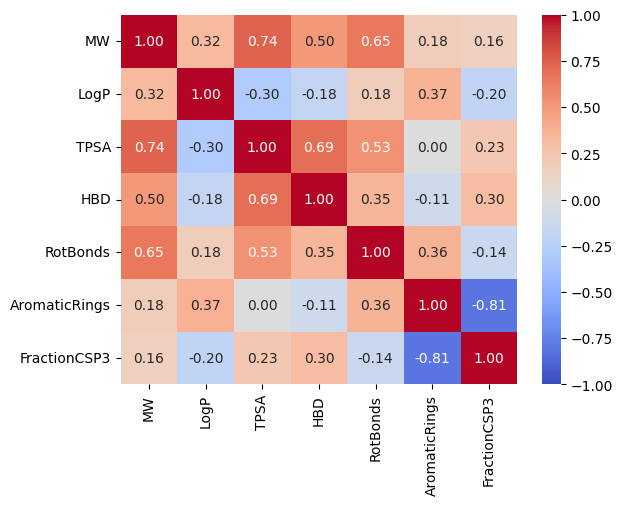

In [56]:
# Correlation
corr = desc_df_refchem.corr() # 1: positive corr, 0: no corr, -1: negative corr
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.show()

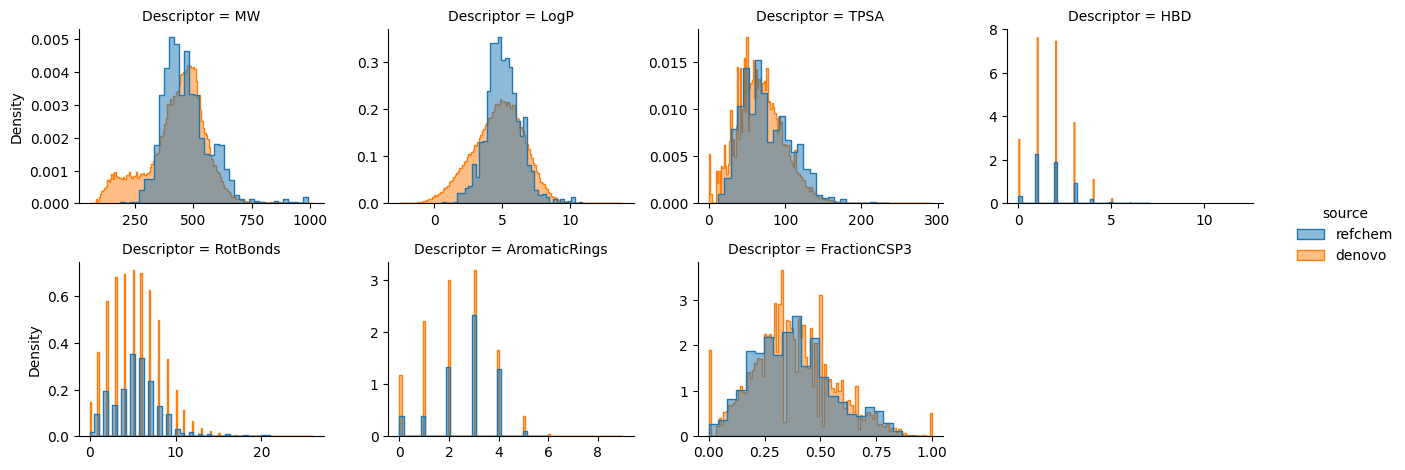

In [57]:
# Histograms
# Add source to descriptor datasets
desc_df_refchem['source'] = 'refchem'
desc_df_denovo['source'] = 'denovo'
# Concatenate the two dataframes
desc_all = pd.concat([desc_df_refchem, desc_df_denovo], axis=0)

# Plot histograms
g = sns.displot(
    desc_all.melt(id_vars='source', var_name='Descriptor', value_name='Value'),
    x='Value', hue='source', col='Descriptor', col_wrap=4,
    kind='hist', element='step', alpha=0.5, common_norm=False, common_bins=False, stat='density',
    height=2.5, aspect=1.3, facet_kws={'sharex': False, 'sharey': False}
)

g.set(xlabel=None)
plt.show()

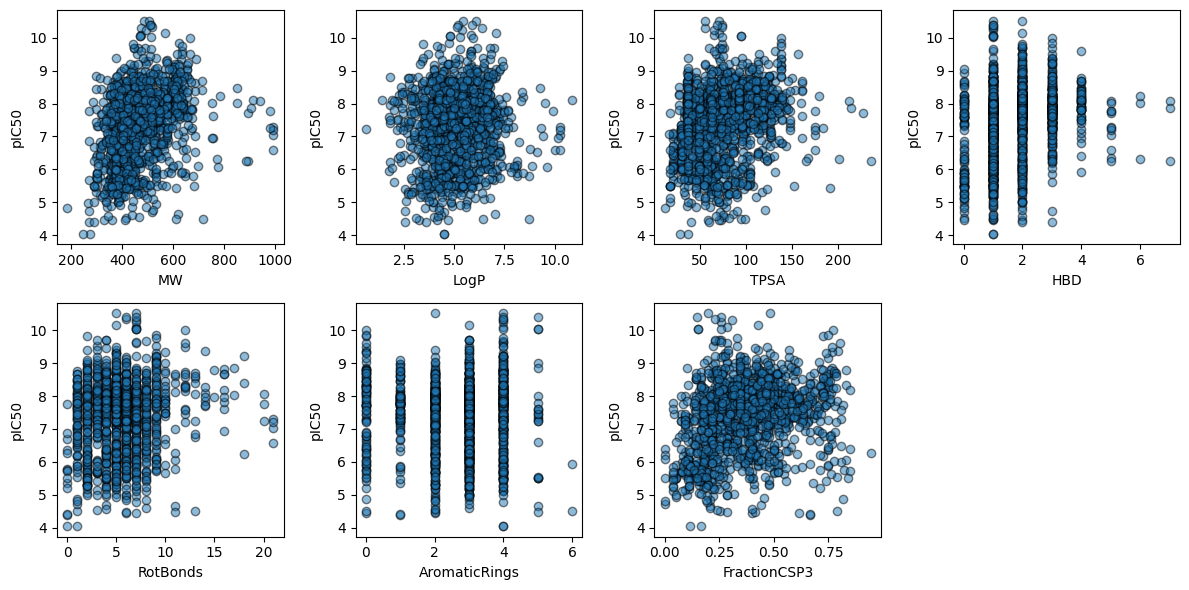

In [58]:
# Scatter plot of each descriptor against pIC50
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']
act_col = "pIC50"

# Create a clean grid using standard matplotlib subplots
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, feat in enumerate(desc_cols):
    axes[i].scatter(df_refchem_clean[feat], df_refchem_clean[act_col], alpha=0.5, edgecolor="k")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(act_col)
axes[i+1].set_axis_off()

plt.tight_layout()
plt.show()

In [59]:
from collections import defaultdict

# Generate scaffold for test/train set splitting
def generate_scaffold(mol):
    if mol is None:
        return None
    # Extract Bemis-Murcko scaffold
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

df_refchem_clean['scaffold'] = df_refchem_clean['mol'].apply(generate_scaffold)

print(f"{len(df_refchem_clean)} structures")
print(f"{df_refchem_clean['scaffold'].nunique()} scaffolds")

1460 structures
547 scaffolds


## 3. QSAR model

Model: Random Forest

1. **Model**:
  - Split data in <u>train/test set</u>
  - <u>Scale</u> data + <u>Train</u> model:
    - Choose a set of *hyperparameters*
    - For each, *train* the model using *CVfold* $\rightarrow$ Calculate R2 for each held-out-fold and average them
    - At the end, chose the hyperparameter set that yield the best average CV R2

2. **Validation**:
  - <u>Internal validation</u> (robustness): *CVfold*; metrics: R2, RMSE, MAE
  - <u>External validation</u> (predictive power): evaluate test set; metrics: R2, RMSE, MAE

3. **Applicability domain**:
  - *William's plot* on the training/test set
  - *Tanimoto NN similarity* (fingerprint) + *Leverage* (descrittori) on the de novo molecules

4. **Prediction**:
  - Predict pIC50 for the  *de novo* dataset

### Random Forest

An ensemble of decision trees, each trained on a <u>random bootstrap sample</u> of the training data (random subset with possible replicas or missing data), with each split considering only a <u>random subset of features</u>.

Final prediction = average (regression) or majority vote (classification) across all trees.

This double randomization (bagging rows + random feature subsets per split) decorrelates the trees, so averaging them reduces variance without adding bias - the core reason RF resists overfitting better than a single deep decision tree.

#### Hyperparameters

- `n_estimators` - number of trees. More trees reduce variance from bootstrap sampling; performance plateaus (doesn't overfit by adding more), so it's mainly a compute-cost tradeoff, not something you need to tune tightly.

- `max_depth` - max depth per tree. Deeper trees fit finer patterns (lower bias per tree) but risk memorizing noise. Unlimited depth (None) is common in RF since averaging tames overfitting, but capping it helps on small datasets (~1500 compounds) and speeds up training.

>- `max_features` - number of features considered at each split. Lower values → more decorrelated trees (better variance reduction) but each split is weaker/more random. This is usually the most impactful hyperparameter to tune.

>- `min_samples_split` - minimum samples required to split a node. Higher values → shallower, more conservative trees, reduces overfitting (controls when splitting starts as: when is a group big enough to consider dividing?).

>- `min_samples_leaf` - minimum samples required in a leaf. Similar effect: higher values smooth predictions, prevent trees from isolating single/few outlier points (controls when splitting ends as: how small are the resulting groups allowed to be in a division?).

- `bootstrap` - whether each tree trains on a bootstrap resample (default True) or the full dataset. Keeping it True is what makes it a random forest rather than a bagging ensemble of identical trees.

Broadly: `max_features`, `max_depth`, and `min_samples_leaf` control the bias-variance tradeoff of individual trees; `n_estimators` controls how much averaging smooths out that variance.

Note: Scaling data is not strictly necessary with Random Forest


### 3.1 Model

Split dataset and train model.

In [60]:
RANDOM_STATE=42

In [61]:
# Flatten fingerprints and create features and target arrays
# Descriptors
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']
X_desc = df_refchem_clean[desc_cols].values

# Fingerprint
fp_col = 'fp'
X_fp = np.vstack(df_refchem_clean[fp_col].values)

# To label important features later
fp_cols = [f"fp_{i}" for i in range(2048)]

# Define feature and target datasets (n_molecules x n_features)
features = ['fp', 'MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']
target = "pIC50"

X = np.hstack([X_desc, X_fp])
y = df_refchem_clean[target]

In [62]:
# Split data in train/test (20% test size)

# Random split? Else scaffold split
random_split = True

if random_split:
  X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
      X, y, df_refchem_clean.index, test_size=0.2, random_state=RANDOM_STATE
  )
  groups_train=None
else:
  # Extract unique scaffolds and shuffle them
  scaffolds = df_refchem_clean['scaffold'].values
  unique_scaffolds = pd.Series(scaffolds).unique()
  rng = np.random.RandomState(RANDOM_STATE)
  rng.shuffle(unique_scaffolds)

  # Select test set scaffolds
  n_test_scaffolds = int(len(unique_scaffolds) * 0.2)
  test_scaffolds = set(unique_scaffolds[:n_test_scaffolds])

  # Define test and train scaffold masks
  test_mask = df_refchem_clean['scaffold'].isin(test_scaffolds).values
  train_mask = ~test_mask

  # Build train and test set
  X_train, X_test = X[train_mask], X[test_mask]
  y_train, y_test = y[train_mask], y[test_mask]
  # Scaffold associated to each training data for GroupKFold
  groups_train = scaffolds[train_mask]

print("Training molecules:", len(X_train))
print("Test molecules:", len(X_test))

Training molecules: 1168
Test molecules: 292


In [63]:
# Create a scaling + model Pipeline
# 1. Define descriptor columns (only descriptors, not fingerprints, should be scaled)
n_desc = X_desc.shape[1]
desc_idx = list(range(0, n_desc))

# 2. Set up the ColumnTransformer to scale the descriptors, leaving fingerprints alone ("passthrough")
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_desc", StandardScaler(), desc_idx)
    ],
    remainder="passthrough"
)

# 3. Create a Pipeline that chains scaling and the model
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

In [64]:
# Train model (hyperparameter tuning)

# Hyperparameters search space
param_dist = {
    "rf__n_estimators": randint(200, 500),
    "rf__max_depth": [10, 15, 20, 30, None],
    "rf__max_features": ["sqrt", 0.1, 0.15, 0.2, 0.25],
    "rf__min_samples_split": [2, 3, 4, 5, 8, 12],
    "rf__min_samples_leaf": [1, 2, 3, 4, 6],
    "rf__bootstrap": [True],
}

# Configure CVFold
if groups_train is not None:  # if scaffold split
  cv = GroupKFold(n_splits=5)
  cv_split = cv.split(X_train, y_train, groups=groups_train)
else:                         # if random split
  cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
  cv_split = cv

# Configure the randomized search to find the optimal hyperparameter set
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,                     # test 20 random combinations of hyperparameters
    scoring="r2",                  # evaluate performance of each set with R2
    cv=cv_split,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

# Run the randomized search
search.fit(X_train, y_train)

# Extract and save the highest performing model
best_model = search.best_estimator_

print("\nBest parameters:", search.best_params_)
print(f"Best CV R²: {search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'rf__bootstrap': True, 'rf__max_depth': None, 'rf__max_features': 0.25, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 208}
Best CV R²: 0.657


In [65]:
# Refit the model with the selected hyperparameters on the whole training set (should already be done)
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale_desc',
                                                  StandardScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6])])),
                ('rf',
                 RandomForestRegressor(max_features=0.25, n_estimators=208,
                                       n_jobs=-1, random_state=42))])

### 3.2 Validation

- Internal validation
- External validation

In [66]:
# Internal validation - CVFold

if groups_train is not None:        # if scaffold split
    cv_diag = GroupKFold(n_splits=5)
    # Prediction for the training set via CVFold
    y_cv_pred = cross_val_predict(best_model, X_train, y_train, cv=cv_diag, groups=groups_train, n_jobs=-1)
else:                               # if random split
    cv_diag = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    # Predictions for the training set
    y_cv_pred = cross_val_predict(best_model, X_train, y_train, cv=cv_diag, n_jobs=-1)

# Compute R2, MAE and RMSE
r2 = r2_score(y_train, y_cv_pred)
mae = mean_absolute_error(y_train, y_cv_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_cv_pred))

print(f"Internal CV R²:   {r2:.3f}")
print(f"Internal CV MAE:  {mae:.3f}")
print(f"Internal CV RMSE: {rmse:.3f}")

Internal CV R²:   0.661
Internal CV MAE:  0.466
Internal CV RMSE: 0.640


In [67]:
# External validation - Test set prediction
y_test_pred = best_model.predict(X_test)

# Compute R2, MAE and RMSE
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"External R²:   {r2:.3f}")
print(f"External MAE:  {mae:.3f}")
print(f"External RMSE: {rmse:.3f}")

External R²:   0.634
External MAE:  0.463
External RMSE: 0.626


In [68]:
# In-sample and R2 comparison

# Use the model to predict the training set (to check if there is underfitting or overfitting)
y_train_pred_insample = best_model.predict(X_train)

print(f"Train R² (in-sample): {r2_score(y_train, y_train_pred_insample):.3f}")  # In-sample (training set)
print(f"CV R² (out-of-fold, train): {r2_score(y_train, y_cv_pred):.3f}")        # Internal validation (CV)
print(f"Test R² (hold-out): {r2_score(y_test, y_test_pred):.3f}")               # External validation (test set)

Train R² (in-sample): 0.943
CV R² (out-of-fold, train): 0.661
Test R² (hold-out): 0.634


Results with *random split*:
```
External R²:   0.634
External MAE:  0.463
External RMSE: 0.626

Train R² (in-sample): 0.943
CV R² (out-of-fold, train): 0.661
Test R² (hold-out): 0.634
```
Results with *scaffold split*:
```
External R²:   0.417
External MAE:  0.590
External RMSE: 0.791

Train R² (in-sample): 0.946
CV R² (out-of-fold, train): 0.546
Test R² (hold-out): 0.417
```

The difference between R² from internal and external validation is an indicator of the model ability to generalize. As expected, with random splitting the model appears to be better than with scaffold splitting.

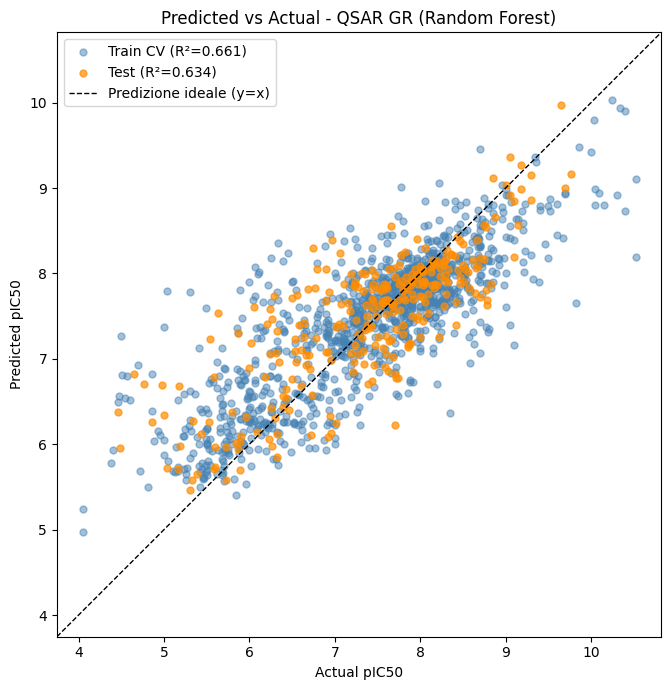

In [69]:
split_type = 'random' if random_split else 'scaffold'      # For plot names

# Plot predicted vs real
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_train, y_cv_pred, alpha=0.5, s=25, color="steelblue",
           label=f"Train CV (R²={r2_score(y_train, y_cv_pred):.3f})")
ax.scatter(y_test, y_test_pred, alpha=0.7, s=25, color="darkorange",
           label=f"Test (R²={r2_score(y_test, y_test_pred):.3f})")

lims = [
    min(y_train.min(), y_test.min()) - 0.3,
    max(y_train.max(), y_test.max()) + 0.3,
]
ax.plot(lims, lims, "k--", linewidth=1, label="Predizione ideale (y=x)")

ax.set_xlabel("Actual pIC50")
ax.set_ylabel("Predicted pIC50")
ax.set_title("Predicted vs Actual - QSAR GR (Random Forest)")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(f"drive/MyDrive/data/predicted_vs_actual_{split_type}.png", dpi=150, bbox_inches="tight")
plt.show()

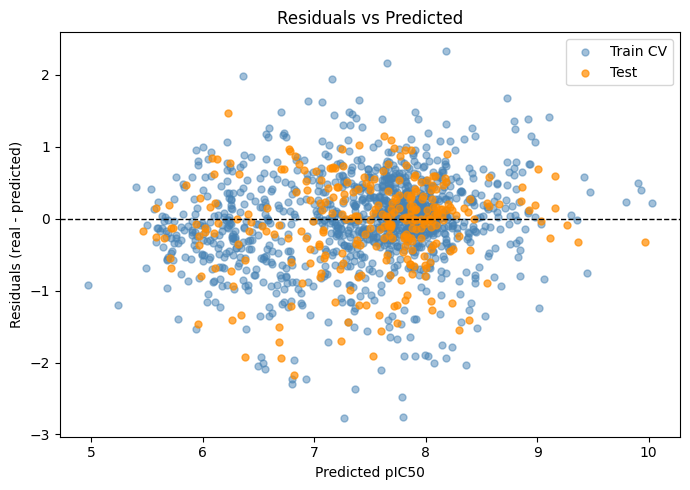

In [70]:
# Plot residuals vs predicted (to check if there is any bias)
fig, ax = plt.subplots(figsize=(7, 5))

resid_train_plot = y_train - y_cv_pred
resid_test_plot = y_test - y_test_pred

ax.scatter(y_cv_pred, resid_train_plot, alpha=0.5, s=25, color="steelblue", label="Train CV")
ax.scatter(y_test_pred, resid_test_plot, alpha=0.7, s=25, color="darkorange", label="Test")
ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Predicted pIC50")
ax.set_ylabel("Residuals (real - predicted)")
ax.set_title("Residuals vs Predicted")
ax.legend()

plt.tight_layout()
plt.savefig(f"drive/MyDrive/data/residuals_plot_{split_type}.png", dpi=150, bbox_inches="tight")
plt.show()

In [71]:
# Feature importance
ordered_feature_names = desc_cols + fp_cols
rf_step = best_model.named_steps["rf"]
importances = pd.Series(rf_step.feature_importances_, index=ordered_feature_names)
top_features = importances.sort_values(ascending=False).head(25)
print("\nTop 25 features by importance:")
print(top_features)


Top 25 features by importance:
FractionCSP3     0.100425
MW               0.076630
HBD              0.040542
LogP             0.033974
TPSA             0.028758
fp_1095          0.016657
fp_43            0.016108
fp_348           0.015761
fp_11            0.014087
fp_1237          0.011915
RotBonds         0.010651
fp_1928          0.009974
fp_807           0.009352
fp_1440          0.007535
fp_679           0.007338
fp_319           0.006131
fp_1436          0.005992
AromaticRings    0.005725
fp_231           0.005465
fp_409           0.005191
fp_476           0.005082
fp_329           0.005078
fp_192           0.004853
fp_1665          0.004811
fp_872           0.004800
dtype: float64


With *random split*:
```
Top 25 features by importance:
FractionCSP3     0.100425
MW               0.076630
HBD              0.040542
LogP             0.033974
TPSA             0.028758
fp_1095          0.016657
fp_43            0.016108
fp_348           0.015761
fp_11            0.014087
fp_1237          0.011915
RotBonds         0.010651
fp_1928          0.009974
fp_807           0.009352
fp_1440          0.007535
fp_679           0.007338
fp_319           0.006131
fp_1436          0.005992
AromaticRings    0.005725
fp_231           0.005465
fp_409           0.005191
fp_476           0.005082
fp_329           0.005078
fp_192           0.004853
fp_1665          0.004811
fp_872           0.004800
```

With *scaffold split*:
```
Top 25 features by importance:
FractionCSP3     0.091029
MW               0.083982
HBD              0.052467
TPSA             0.034399
LogP             0.029692
fp_348           0.021216
fp_43            0.011546
fp_11            0.011104
fp_1095          0.010914
fp_1436          0.010723
RotBonds         0.009107
fp_1237          0.008241
fp_476           0.007682
fp_1905          0.007607
fp_319           0.007423
fp_1295          0.007244
fp_1440          0.007101
AromaticRings    0.005871
fp_192           0.005814
fp_1825          0.005651
fp_679           0.005260
fp_675           0.005194
fp_84            0.005165
fp_231           0.004724
fp_1057          0.004721
```

### 3.3 Applicability Domain

- *William's plot* on the training/test set
- *Tanimoto NN similarity* (fingerprint) + *Leverage* (descrittori) on the de novo molecules

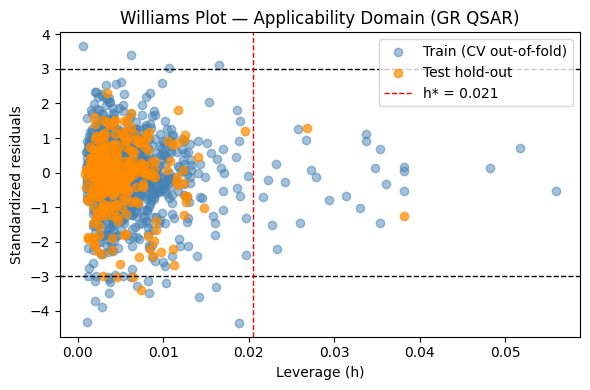


Williams plot: h* = 0.021
Test set - 'bad leverage' points (h > h*, |resid std| > 3): 0 / 292


In [72]:
# William's plot (leverage vs residuals)

# Extract the scaler from the fitted pipeline
fitted_scaler = best_model.named_steps["preprocessor"].named_transformers_["scale_desc"]

# Scale descriptors (using the learned mean and stddev)
X_train_desc_scaled = fitted_scaler.transform(X_train[:, desc_idx])
X_test_desc_scaled = fitted_scaler.transform(X_test[:, desc_idx])

# Calculate hat matrix
XtX_inv = np.linalg.pinv(X_train_desc_scaled.T @ X_train_desc_scaled)
# Calculate LEVERAGE for train and test set ("how close data are to the centroid of the space")
h_train = np.array([x @ XtX_inv @ x.T for x in X_train_desc_scaled])
h_test = np.array([x @ XtX_inv @ x.T for x in X_test_desc_scaled])

# Calculate OECD threshold
p = X_train_desc_scaled.shape[1]  # num_descriptors
n = X_train_desc_scaled.shape[0]  # num_data
h_star = 3 * (p + 1) / n

# Calculate standardized RESIDUALS (prediction errors normalized by standard deviation)
resid_train = y_train - y_cv_pred
std_resid_train = resid_train / np.std(resid_train)

resid_test = y_test - y_test_pred
std_resid_test = resid_test / np.std(resid_train)  # std of the TRAIN, non test set (in general std of new data is not known)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(h_train, std_resid_train, alpha=0.5, label="Train (CV out-of-fold)", color="steelblue")
ax.scatter(h_test, std_resid_test, alpha=0.7, label="Test hold-out", color="darkorange")

# Resiudals threshold
ax.axhline(3, color="black", linestyle="--", linewidth=1)
ax.axhline(-3, color="black", linestyle="--", linewidth=1)

# Leverage threshold
ax.axvline(h_star, color="red", linestyle="--", linewidth=1, label=f"h* = {h_star:.3f}")

ax.set_xlabel("Leverage (h)")
ax.set_ylabel("Standardized residuals")
ax.set_title("Williams Plot — Applicability Domain (GR QSAR)")
ax.legend()
plt.tight_layout()
plt.savefig(f"williams_plot_train_test_{split_type}.png", dpi=150)
plt.show()

bad_leverage_test = np.sum((h_test > h_star) & (np.abs(std_resid_test) > 3))
print(f"\nWilliams plot: h* = {h_star:.3f}")
print(f"Test set - 'bad leverage' points (h > h*, |resid std| > 3): {bad_leverage_test} / {len(h_test)}")

There are some high residuals (bad predictions) among low leverage structures. There are no compounds that are both high leverage (far from domain) and high residual (bad prediction).

In [73]:
"""
# To assess belonging to applicability domain of new molecules
from sklearn.neighbors import NearestNeighbors

# Fingerprints
def tanimoto_nn_distance(fp_train, fp_query):
    """   """
    Tanimoto similarity to nearest neighbor in training set
    fp_train, fp_query: binary array (fingerprints)
    """   """
    nn = NearestNeighbors(n_neighbors=1, metric="jaccard", n_jobs=-1)
    nn.fit(fp_train)
    distances, _ = nn.kneighbors(fp_query)
    similarities = 1 - distances.ravel()
    return similarities

# Descriptors
def leverage(X_train_desc, X_query_desc):
    """   """
    Leverage h_i = x_i (X^T X)^-1 x_i^T for each line in X_query_desc
    X_train_desc, X_query_desc: SCALED descriptors
    """   """
    XtX_inv = np.linalg.pinv(X_train_desc.T @ X_train_desc)
    h = np.array([x @ XtX_inv @ x.T for x in X_query_desc])
    return h
"""

In [74]:
# Save pipeline
joblib.dump(best_model, f"drive/MyDrive/data/gr_rf_qsar_pipeline_{split_type}.pkl")
print(f"Pipeline (scaler + RF) saved in gr_rf_qsar_pipeline_{split_type}.pkl")
print("To score new molecoles: pipeline.predict(X_new) - scaling is included in the pipeline")

Pipeline (scaler + RF) saved in gr_rf_qsar_pipeline_random.pkl
To score new molecoles: pipeline.predict(X_new) - scaling is included in the pipeline


### 3.4 Prediction
  - Predict pIC50 for the *de novo* dataset
  - Check applicability domain (NN Tanimoto similarity for fingerprints, leverage for descriptors)

In [90]:
# Features columns
FP_COL = "fp"
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']

# Build de novo features dataset
# Descriptors
X_denovo_desc = df_denovo_clean[desc_cols].values.astype(np.float32)
# Fingerprints
X_denovo_fp = np.vstack(df_denovo_clean[FP_COL].values)
# Merge them
X_denovo = np.hstack([X_denovo_desc, X_denovo_fp]).astype(np.float32)

print(f"De novo molecules to score: {X_denovo.shape[0]}")
print(f"Number of features in the dataset: {X_denovo.shape[1]}")

De novo molecules to score: 99876
Number of features in the dataset: 2055


#### Prediction

In [92]:
# Prediction using the trained QSAR model (scaling is already included in the pipeline)
# Performed in batches due to Google Colab RAM limitations
def predict_in_batches(pipeline, X, batch_size=10000):
    n = X.shape[0]
    predictions = np.empty(n, dtype=np.float32)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        predictions[start:end] = pipeline.predict(X[start:end])
        if start % 50000 == 0:
            print(f"Processed {end}/{n} molecules...")
    print("Done")
    return predictions

df_denovo_clean["pIC50_pred"] = predict_in_batches(best_model, X_denovo, batch_size=10000)

Processed 10000/99876 molecules...
Processed 60000/99876 molecules...
Done


#### Applicability Domain

In [105]:
# Descriptors: Leverage
# Scale descriptors (with the model scaler)
fitted_scaler = best_model.named_steps["preprocessor"].named_transformers_["scale_desc"]

X_denovo_desc_raw = df_denovo_clean[desc_cols].values.astype(np.float32)
X_denovo_desc_scaled = fitted_scaler.transform(X_denovo_desc_raw).astype(np.float32)
del X_denovo_desc_raw
gc.collect()

# XtX_inv calculated on the TRAINING set
# Leverage (vectorized for efficiency): h_i = x_i @ XtX_inv @ x_i^T for each line
h_denovo = np.einsum('ij,jk,ik->i', X_denovo_desc_scaled, XtX_inv, X_denovo_desc_scaled)

df_denovo_clean["leverage"] = h_denovo
del X_denovo_desc_scaled
gc.collect()

pct_out_of_domain_leverage = (df_denovo_clean["leverage"] > h_star).mean() * 100
print(f"% de novo molecules outside domain (leverage): {pct_out_of_domain_leverage:.1f}%")

% de novo molecules outside domain (leverage): 7.6%


In [123]:
df_denovo_clean['leverage'].describe()

,leverage
count,99876.000000
mean,0.009413
std,0.007645
min,0.000257
25%,0.004575
50%,0.007260
75%,0.011594
max,0.139954


In [117]:
# Fingerprints: NN Tanimoto similarity
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Get fingerprints for the training set
n_desc = len(desc_idx)                  # number of descriptors
n_total = X.shape[1]                    # total columns
fp_idx = list(range(n_desc, n_total))   # fingerprint indeces
X_train_fp = X_train[:, fp_idx].astype(np.int8)

def tanimoto_nn_distance_dense(fp_train, fp_query, batch_size=5000):
    """
    Tanimoto (Jaccard) similarity to nearest neighbor,
    with batch processing for efficiency
    fp_train, fp_query: binary array (fingerprints)
    """
    # Set up NN search
    fp_train = fp_train.astype(np.int8)
    nn = NearestNeighbors(n_neighbors=1, metric="jaccard", algorithm="brute", n_jobs=-1)
    nn.fit(fp_train)

    n = fp_query.shape[0]   # num_data
    similarities = np.empty(n, dtype=np.float32)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = fp_query[start:end].astype(np.int8)
        distances, _ = nn.kneighbors(batch)
        similarities[start:end] = 1 - distances.ravel()
        if start % (batch_size * 5) == 0:
            print(f"[Tanimoto NN] Processed {end}/{n} molecules...")
    print("Done")
    return similarities

sim_denovo = tanimoto_nn_distance_dense(X_train_fp, X_denovo_fp, batch_size=5000)
df_denovo_clean["tanimoto_nn_sim"] = sim_denovo

del X_denovo_fp
gc.collect()

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


[Tanimoto NN] Processed 5000/99876 molecules...


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


[Tanimoto NN] Processed 30000/99876 molecules...


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


...

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


[Tanimoto NN] Processed 80000/99876 molecules...


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Done


735

In [122]:
df_denovo_clean['tanimoto_nn_sim'].describe()

,tanimoto_nn_sim
count,99876.000000
mean,0.406570
std,0.171921
min,0.039474
25%,0.266055
50%,0.383562
75%,0.525000
max,1.000000


In [ ]:
# Visualize leverage and NN Tanimoto similarity


In [127]:
# Combined (Leverage + Tanimoto NN) confidence flag
LEVERAGE_THRESHOLD = h_star   # calculated on training set (Williams plot)
TANIMOTO_THRESHOLD = 0.3      # adjust based on data

df_denovo_clean["out_of_domain_leverage"] = df_denovo_clean["leverage"] > LEVERAGE_THRESHOLD
df_denovo_clean["out_of_domain_tanimoto"] = df_denovo_clean["tanimoto_nn_sim"] < TANIMOTO_THRESHOLD

df_denovo_clean["low_confidence"] = (
    df_denovo_clean["out_of_domain_leverage"] | df_denovo_clean["out_of_domain_tanimoto"]
)

print(f"\nTotal molecules: {len(df_denovo_clean)}")
print(f"Out of domain for leverage:  {df_denovo_clean['out_of_domain_leverage'].sum()} "
      f"({100 * df_denovo_clean['out_of_domain_leverage'].mean():.1f}%)")
print(f"Out of domain for Tanimoto:  {df_denovo_clean['out_of_domain_tanimoto'].sum()} "
      f"({100 * df_denovo_clean['out_of_domain_tanimoto'].mean():.1f}%)")
print(f"Low confidence (union):  {df_denovo_clean['low_confidence'].sum()} "
      f"({100 * df_denovo_clean['low_confidence'].mean():.1f}%)")


Total molecules: 99876
Out of domain for leverage:  7574 (7.6%)
Out of domain for Tanimoto:  32850 (32.9%)
Low confidence (union):  34282 (34.3%)


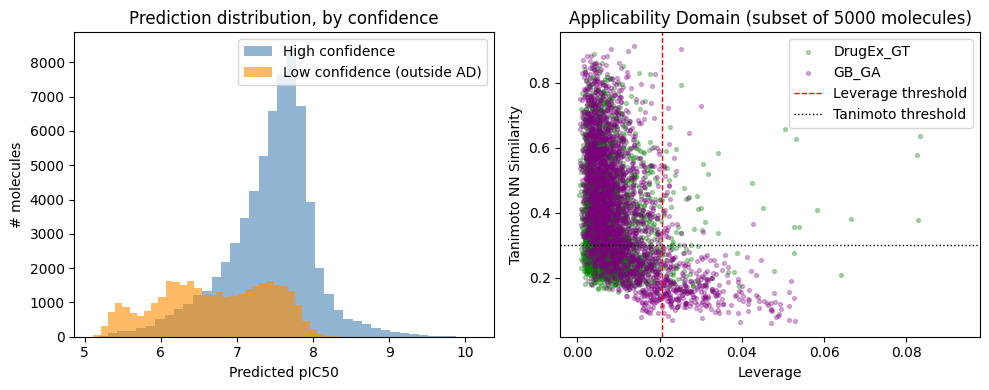

In [140]:
# Inspect prediction distribution and confidence
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(df_denovo_clean.loc[~df_denovo_clean["low_confidence"], "pIC50_pred"],
             bins=40, alpha=0.6, label="High confidence", color="steelblue")
axes[0].hist(df_denovo_clean.loc[df_denovo_clean["low_confidence"], "pIC50_pred"],
             bins=40, alpha=0.6, label="Low confidence (outside AD)", color="darkorange")
axes[0].set_xlabel("Predicted pIC50")
axes[0].set_ylabel("# molecules")
axes[0].set_title("Prediction distribution, by confidence")
axes[0].legend()

# Scatter plot (on selected sample)
plot_sample = df_denovo_clean.sample(n=min(5000, len(df_denovo_clean)), random_state=RANDOM_STATE)
for src, color in [("DrugEx_GT", "green"), ("GB_GA", "purple")]:
    subset = plot_sample[plot_sample["source"] == src]
    axes[1].scatter(subset["leverage"], subset["tanimoto_nn_sim"],
                     alpha=0.3, s=8, color=color, label=src)
axes[1].axvline(LEVERAGE_THRESHOLD, color="red", linestyle="--", linewidth=1, label="Leverage threshold")
axes[1].axhline(TANIMOTO_THRESHOLD, color="black", linestyle=":", linewidth=1, label="Tanimoto threshold")
axes[1].set_xlabel("Leverage")
axes[1].set_ylabel("Tanimoto NN Similarity")
axes[1].set_title("Applicability Domain (subset of 5000 molecules)")
axes[1].legend()

plt.tight_layout()
plt.savefig("drive/MyDrive/data/denovo_scoring_ad_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Interestingly, the low confidence prediction tend to have lower pIC50 values. This might point to a tendency of the model to predict low activities when it extrapolates.

In [142]:
# Save to a file
df_denovo_clean.to_csv(f"drive/MyDrive/data/denovo_predictions_{split_type}.csv", index=False)
print(f"Predictions saved in denovo_predictions_{split_type}.csv")

Predictions saved in denovo_predictions_random.csv


## What to analyze

- Do the two generators produce different <u>SAScore</u> distributions?

- Do the most <u>drug-like</u> molecules also remain <u>synthetically accessible</u>?

- How many top-ranked molecules by the <u>QSAR</u> model score below acceptable thresholds for the <u>other scoring</u> components?
Use the publications of the respective methods to find reasonable thresholds.

- Do the *highest-ranked non-steroidal* molecules still remain close to the *reference chemistry*, or do they drift into new space?